In [82]:
!pip install ucimlrepo


images - eps format
600dpi  
x axis , y axis, labels, legend -> times new roman ,bold ,
size = 15

In [83]:
from ucimlrepo import fetch_ucirepo

banknote_authentication = fetch_ucirepo(id=267)

X = banknote_authentication.data.features
y = banknote_authentication.data.targets

print(banknote_authentication.metadata)

print(banknote_authentication.variables)
print(X.shape)


{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

In [3]:
import pandas as pd
import itertools
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
scaler = StandardScaler()


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("times.ttf")

fm._load_fontmanager(try_read_cache=False)

print([f.name for f in fm.fontManager.ttflist if "Times" in f.name])


['Times New Roman', 'Times New Roman']


In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['font.size'] = 15


In [87]:
X.head()


,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [88]:
X.shape


(1372, 4)

In [89]:
X.isna().sum()


,0
variance,0
skewness,0
curtosis,0
entropy,0


In [90]:
X.describe()


,variance,skewness,curtosis,entropy
count,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657
std,2.842763,5.869047,4.310030,2.101013
min,-7.042100,-13.773100,-5.286100,-8.548200
25%,-1.773000,-1.708200,-1.574975,-2.413450
50%,0.496180,2.319650,0.616630,-0.586650
75%,2.821475,6.814625,3.179250,0.394810
max,6.824800,12.951600,17.927400,2.449500


In [91]:
X.columns


Index(['variance', 'skewness', 'curtosis', 'entropy'], dtype='object')

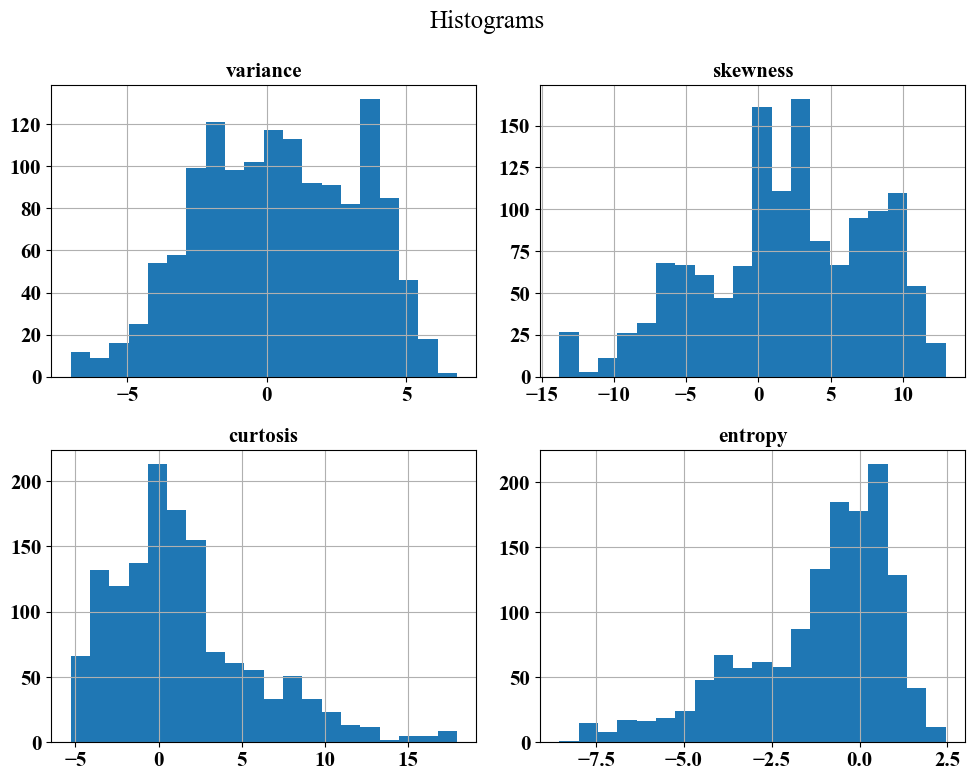

In [92]:
X.hist(figsize=(10, 8), bins=20)
plt.suptitle("Histograms")
plt.tight_layout()

plt.savefig(
    "hist.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


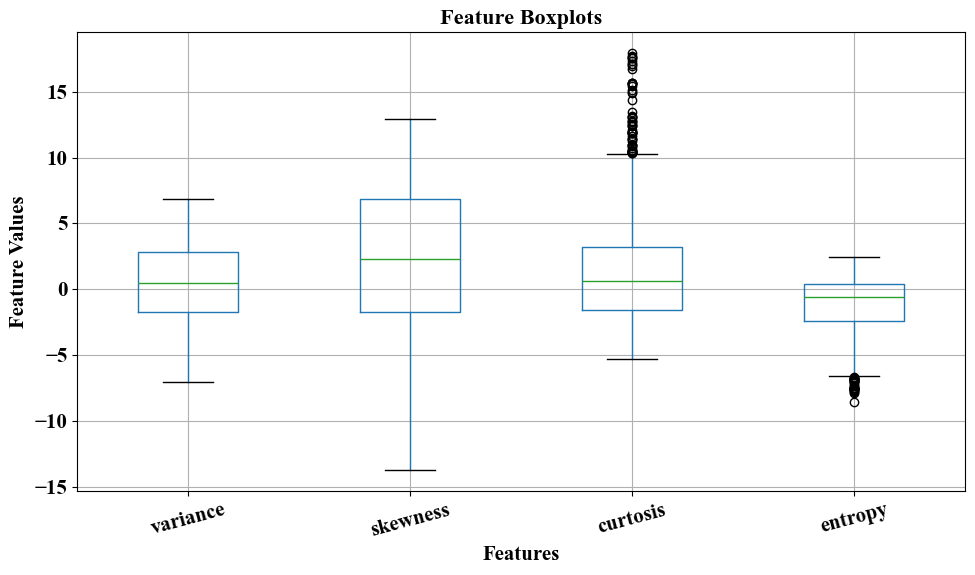

In [93]:
plt.figure(figsize=(10, 6))

X.boxplot()

plt.title("Feature Boxplots", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Feature Values")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("boxplot.eps", format="eps", dpi=600)

plt.show()


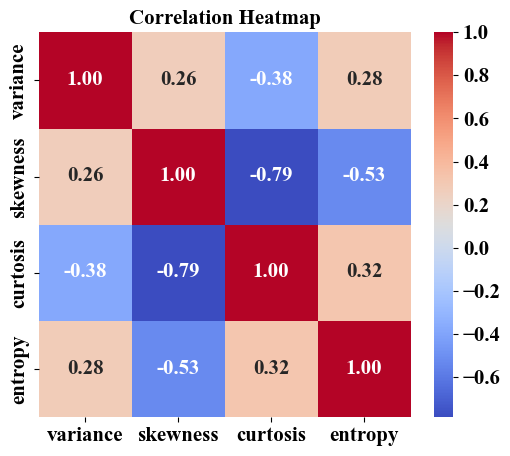

In [94]:
plt.figure(figsize=(6, 5))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

plt.savefig(
    "heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


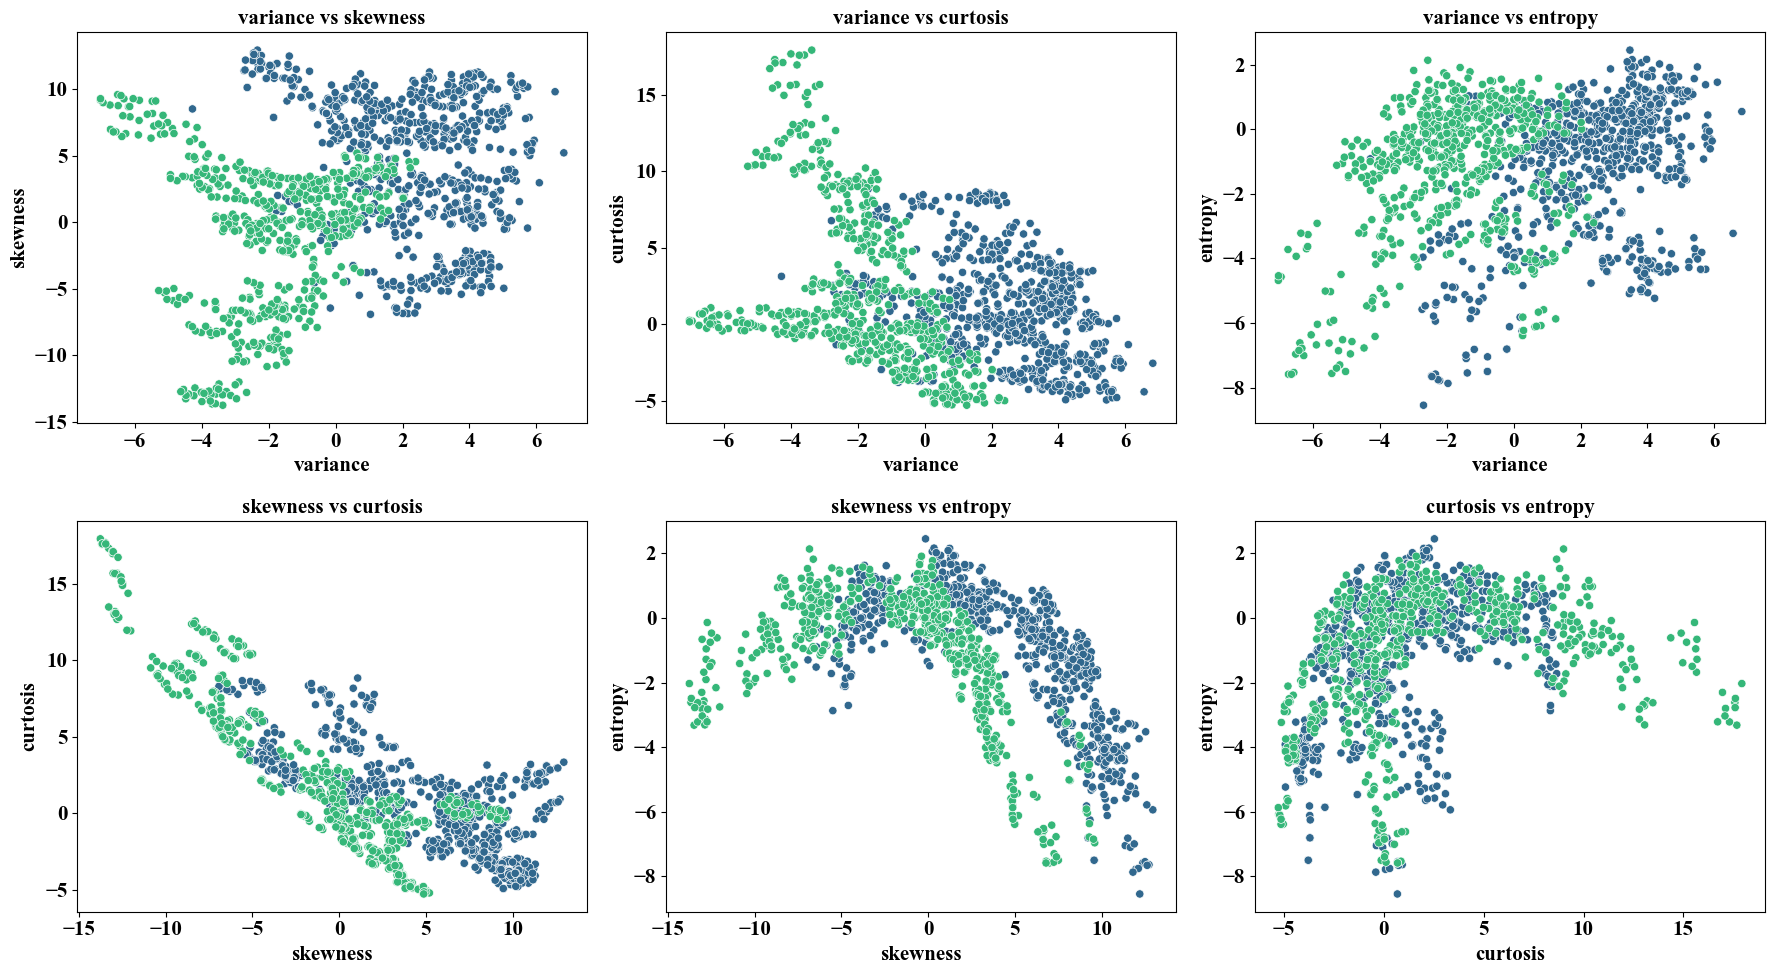

In [95]:
target = y.squeeze()

features = X.columns

pairs = list(itertools.combinations(features, 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (f1, f2) in zip(axes, pairs):
    sns.scatterplot(
        data=X,
        x=f1,
        y=f2,
        hue=target,
        palette="viridis",
        ax=ax,
        legend=False
    )
    ax.set_title(f"{f1} vs {f2}")

plt.tight_layout()

plt.savefig(
    "scatterplot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


In [96]:
weights = torch.randn(4)
bias = torch.randn(1)


In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler.fit_transform(X_train)
scaler.transform(X_test)


array([[ 0.67206974,  0.95146612, -0.31989126, -0.25003035],
       [-0.6719866 ,  0.04589915, -0.4320298 , -0.21511024],
       [-0.4403584 ,  1.30297244, -1.1930052 , -2.98014804],
       ...,
       [ 1.07387089,  0.17520537, -0.08066397,  0.76826281],
       [ 0.26424634,  1.1729549 , -0.82116096,  0.2235849 ],
       [ 1.59245462,  1.09725106, -0.90733147, -0.03250222]])

In [98]:
learning_rate = 0.01


In [99]:
epochs = 100


In [100]:
def step(z):
  if(z >= 0 ):
    return 1.0
  else:
    return 0.0


In [101]:
X.columns


Index(['variance', 'skewness', 'curtosis', 'entropy'], dtype='object')

In [102]:
X = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y = torch.tensor(y_train.values.squeeze(), dtype=torch.float32)


In [103]:
error_history = []
weight_history = []
bias_history = []

for epoch in range(epochs):

    mistakes = 0
    indices = torch.randperm(X.shape[0])

    for i in indices:

        x = X[i]
        target = float(y[i])

        z = torch.dot(weights, x) + bias

        y_pred = step(z)

        error = target - y_pred

        if error != 0:
            mistakes += 1

        weights += learning_rate * error * x
        bias += learning_rate * error

    error_history.append(mistakes)
    weight_history.append(weights.clone().numpy())
    bias_history.append(float(bias))

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:3d} | Errors = {mistakes:3d} | Bias = {bias.item():.4f}"
        )


Epoch   0 | Errors =  85 | Bias = 0.3036
Epoch   5 | Errors =  23 | Bias = 0.6036
Epoch  10 | Errors =  17 | Bias = 0.7236
Epoch  15 | Errors =  20 | Bias = 0.7636
Epoch  20 | Errors =  18 | Bias = 0.8736
Epoch  25 | Errors =  22 | Bias = 0.9436
Epoch  30 | Errors =  15 | Bias = 0.9736
Epoch  35 | Errors =  18 | Bias = 1.0336
Epoch  40 | Errors =  13 | Bias = 1.0436
Epoch  45 | Errors =  16 | Bias = 1.0736
Epoch  50 | Errors =  19 | Bias = 1.1236
Epoch  55 | Errors =  16 | Bias = 1.1636
Epoch  60 | Errors =  19 | Bias = 1.2036
Epoch  65 | Errors =  14 | Bias = 1.2136
Epoch  70 | Errors =  12 | Bias = 1.2336
Epoch  75 | Errors =  15 | Bias = 1.2736
Epoch  80 | Errors =  16 | Bias = 1.2636
Epoch  85 | Errors =  18 | Bias = 1.2636
Epoch  90 | Errors =  16 | Bias = 1.2736
Epoch  95 | Errors =  16 | Bias = 1.3036


In [104]:
final_weights = weights.numpy()
final_bias = bias.item()

print(f"Final Weights: {final_weights}")
print(f"Final Bias: {final_bias}")


Final Weights: [-1.2099257  -0.6791594  -0.78283435 -0.17828037]
Final Bias: 1.3535865545272827


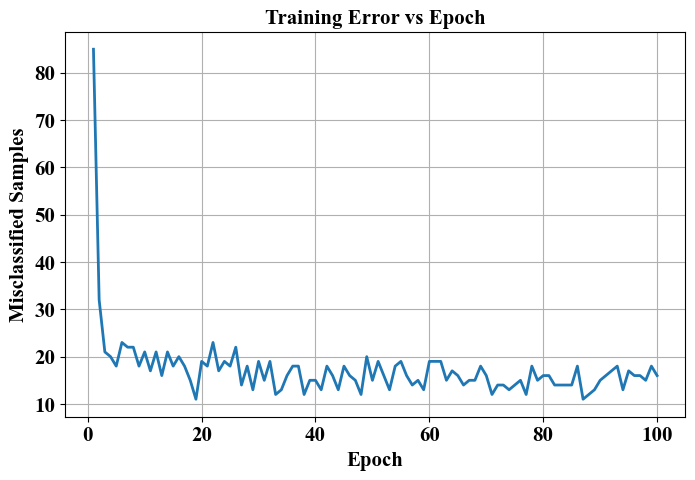

In [105]:
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1), error_history,
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

plt.grid(True)

plt.savefig(
    "trainerror_vs_epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


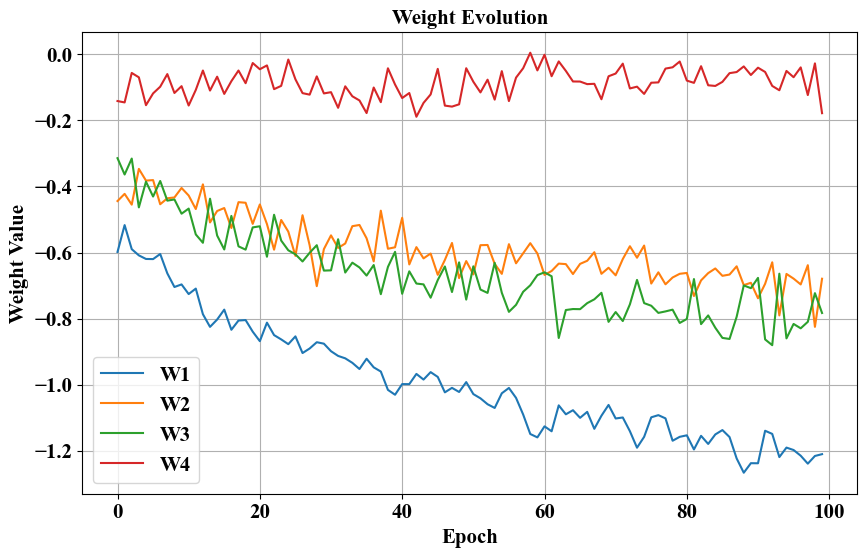

In [106]:
weight_history = np.array(weight_history)

plt.figure(figsize=(10,6))

for i in range(weight_history.shape[1]):
    plt.plot(weight_history[:, i], label=f"W{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")

plt.legend()

plt.grid(True)

plt.savefig(
    "weight_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


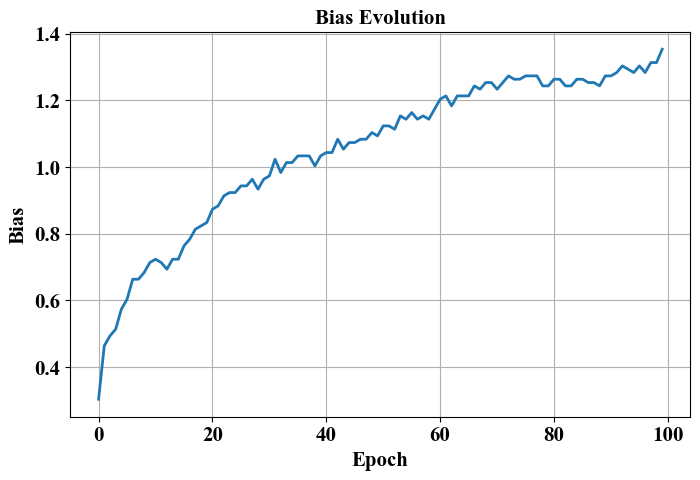

In [107]:
plt.figure(figsize=(8,5))

plt.plot(bias_history, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid(True)
plt.savefig(
    "bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


In [108]:
epoch_table = pd.DataFrame({

    "Epoch": np.arange(1, epochs+1),

    "Errors": error_history,

    "Weight 1": weight_history[:,0],
    "Weight 2": weight_history[:,1],
    "Weight 3": weight_history[:,2],
    "Weight 4": weight_history[:,3],

    "Bias": bias_history
})

epoch_table.head(20)


,Epoch,Errors,Weight 1,Weight 2,Weight 3,Weight 4,Bias
0,1,85,-0.598190,-0.444116,-0.314410,-0.141537,0.303587
1,2,32,-0.516882,-0.422368,-0.363812,-0.145752,0.463587
2,3,21,-0.589689,-0.454999,-0.315590,-0.056543,0.493587
3,4,20,-0.608493,-0.346774,-0.463334,-0.069776,0.513587
4,5,18,-0.619343,-0.382262,-0.385457,-0.154060,0.573587
5,6,23,-0.619747,-0.380730,-0.430466,-0.118422,0.603587
6,7,22,-0.604285,-0.453796,-0.383409,-0.098200,0.663587
7,8,22,-0.662882,-0.435792,-0.442908,-0.059977,0.663587
8,9,18,-0.704160,-0.433184,-0.439265,-0.117149,0.683587
9,10,21,-0.696373,-0.404565,-0.482399,-0.096551,0.713587


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [121]:
selected_epochs = epoch_table[(epoch_table["Epoch"] % 10 == 0 )]

print(selected_epochs)


    Epoch  Errors  Weight 1  Weight 2  Weight 3  Weight 4      Bias
9      10      21 -0.696373 -0.404565 -0.482399 -0.096551  0.713587
19     20      19 -0.839290 -0.513129 -0.523883 -0.026572  0.833587
29     30      19 -0.875639 -0.589552 -0.654533 -0.118496  0.963587
39     40      15 -1.030158 -0.584009 -0.597818 -0.091543  1.033587
49     50      15 -0.991911 -0.625670 -0.742339 -0.042291  1.093587
59     60      19 -1.159181 -0.602787 -0.668169 -0.048815  1.173587
69     70      16 -1.060990 -0.645998 -0.809644 -0.066611  1.253587
79     80      16 -1.157492 -0.664234 -0.812933 -0.022002  1.243587
89     90      15 -1.237271 -0.691446 -0.707714 -0.062723  1.273587
99    100      16 -1.209926 -0.679159 -0.782834 -0.178280  1.353587


In [122]:
selected_epochs = epoch_table[epoch_table["Epoch"] % 10 == 0]

latex_table = selected_epochs.to_latex(
    index=False,
    float_format="%.4f",
    caption="Epoch-wise Learning Progress (Every 10th Epoch)",
    label="tab:epoch_learning"
)

print(latex_table)


\begin{table}
\caption{Epoch-wise Learning Progress (Every 10th Epoch)}
\label{tab:epoch_learning}
\begin{tabular}{rrrrrrr}
\toprule
Epoch & Errors & Weight 1 & Weight 2 & Weight 3 & Weight 4 & Bias \\
\midrule
10 & 21 & -0.6964 & -0.4046 & -0.4824 & -0.0966 & 0.7136 \\
20 & 19 & -0.8393 & -0.5131 & -0.5239 & -0.0266 & 0.8336 \\
30 & 19 & -0.8756 & -0.5896 & -0.6545 & -0.1185 & 0.9636 \\
40 & 15 & -1.0302 & -0.5840 & -0.5978 & -0.0915 & 1.0336 \\
50 & 15 & -0.9919 & -0.6257 & -0.7423 & -0.0423 & 1.0936 \\
60 & 19 & -1.1592 & -0.6028 & -0.6682 & -0.0488 & 1.1736 \\
70 & 16 & -1.0610 & -0.6460 & -0.8096 & -0.0666 & 1.2536 \\
80 & 16 & -1.1575 & -0.6642 & -0.8129 & -0.0220 & 1.2436 \\
90 & 15 & -1.2373 & -0.6914 & -0.7077 & -0.0627 & 1.2736 \\
100 & 16 & -1.2099 & -0.6792 & -0.7828 & -0.1783 & 1.3536 \\
\bottomrule
\end{tabular}
\end{table}



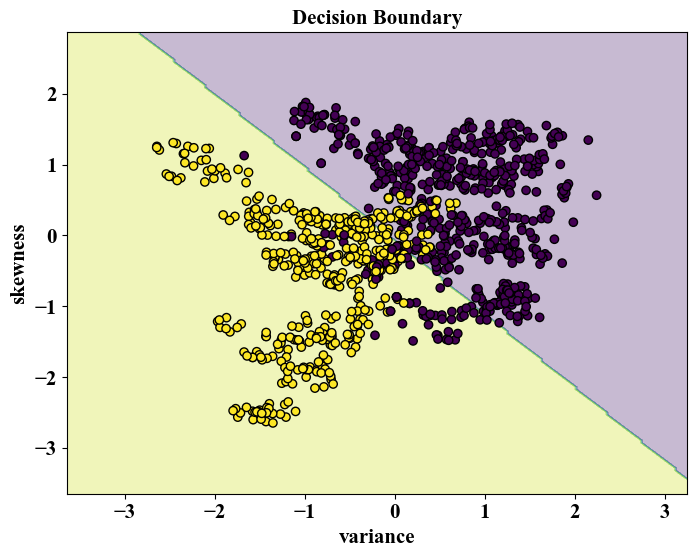

In [109]:
X_vis = X_train.iloc[:, :2]
y_vis = y_train.squeeze()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_vis)

weights = torch.randn(2)
bias = torch.randn(1)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_vis.values, dtype=torch.float32)

for epoch in range(100):

    for i in range(len(X_tensor)):

        x = X_tensor[i]
        target = float(y_tensor[i])

        pred = step(torch.dot(weights, x)+bias)

        error = target-pred

        weights += 0.01*error*x
        bias += 0.01*error

xmin, xmax = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
ymin, ymax = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 200),
    np.linspace(ymin, ymax, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

preds = []

for g in grid_tensor:
    preds.append(step(torch.dot(weights, g)+bias))

preds = np.array(preds).reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, preds, alpha=0.3)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y_vis,
    edgecolors='k'
)

plt.xlabel(X_vis.columns[0])
plt.ylabel(X_vis.columns[1])

plt.title("Decision Boundary")
plt.savefig(
    "descision boundary.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


In [110]:
print(X.shape[0])


1097


In [111]:
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

correct = 0
total = len(X_test_tensor)

predictions = []
weights = torch.from_numpy(final_weights)
for i in range(total):
    output = torch.dot(weights, X_test_tensor[i]) + bias
    pred = step(output)      # 0 or 1
    predictions.append(pred)

    if pred == y_test_tensor[i]:
        correct += 1

accuracy = correct / total

print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 96.36%


Accuracy : 0.9636
Precision: 1.0000
Recall   : 0.9180
F1-score : 0.9573

Confusion Matrix:
[[153   0]
 [ 10 112]]


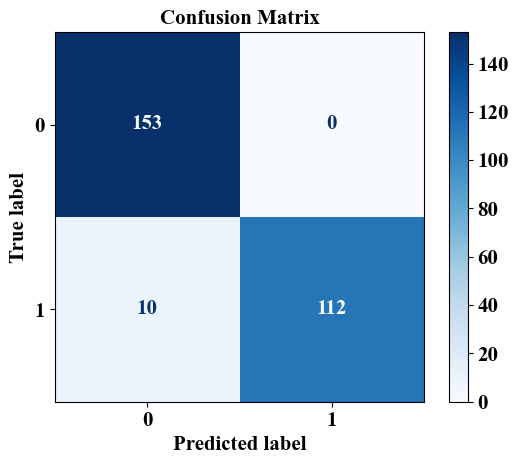

In [112]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

y_pred = predictions
y_true = y_test.to_numpy().astype(int)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig(
    "confusion matrix.eps",
    format="eps",

    bbox_inches="tight"
)
plt.show()


In [113]:
summary = pd.DataFrame({

    "Metric":[
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value":[
        len(X_train)+len(X_test),
        "80/20",
        learning_rate,
        epochs,
        weights.numpy(),
        bias.item(),
        accuracy,
        precision,
        recall,
        f1
    ]
})

summary


,Metric,Value
0,Dataset Size,1372
1,Train/Test Split,80/20
2,Learning Rate,0.01
3,Epochs,100
4,Final Weights,"[-1.2099257, -0.6791594, -0.78283435, -0.17828..."
5,Final Bias,-0.00175
6,Accuracy,0.963636
7,Precision,1.0
8,Recall,0.918033
9,F1-score,0.957265


In [114]:
print("Dataset Size:", X.shape)
print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Final Weights:", weights)
print("Final Bias:", bias)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Dataset Size: torch.Size([1097, 4])
Learning Rate: 0.01
Epochs: 100
Final Weights: tensor([-1.2099, -0.6792, -0.7828, -0.1783])
Final Bias: tensor([-0.0018])
Accuracy: 0.9636363636363636
Precision: 1.0
Recall: 0.9180327868852459
F1-score: 0.9572649572649573


In [115]:
learning_rates = [0.001, 0.01, 0.1]

comparison = {}

for lr in learning_rates:

    weights = torch.randn(4)
    bias = torch.randn(1)

    errors = []

    for epoch in range(epochs):

        mistakes = 0

        indices = torch.randperm(X.shape[0])

        for i in indices:

            x = X[i]
            target = float(y[i])

            pred = step(torch.dot(weights, x) + bias)

            error = target - pred

            if error != 0:
                mistakes += 1

            weights += lr * error * x
            bias += lr * error

        errors.append(mistakes)

    comparison[lr] = errors


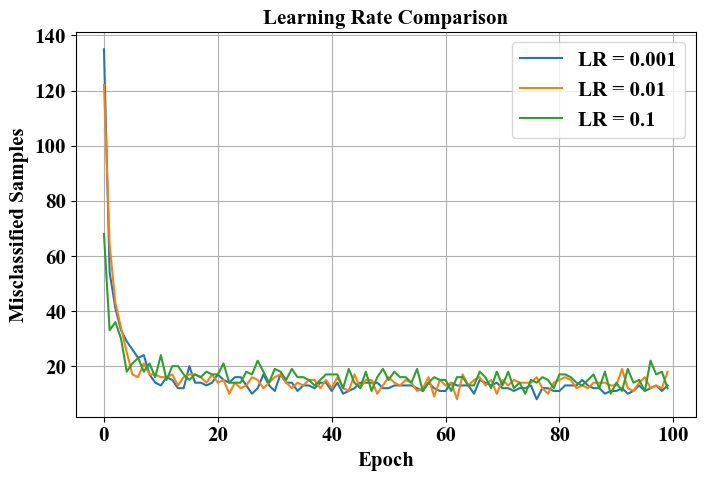

In [116]:
plt.figure(figsize=(8,5))

for lr, errors in comparison.items():
    plt.plot(errors, label=f"LR = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)
plt.savefig(
    "learning_Rate_Comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


In [8]:
X_binary = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_or = np.array([0, 1, 1, 1])
y_and = np.array([0, 0, 0, 1])

X_not = np.array([
    [0],
    [1]
], dtype=float)

y_not = np.array([1, 0])


In [19]:
def gate_step(z):
    return 1 if z >= 0 else 0

def plot_gate_boundary(X, y, weights, bias, gate, update_no):

    if X.shape[1] == 1:
        plt.figure(figsize=(6, 3))

        plt.scatter(
            X[:, 0],
            np.zeros(len(X)),
            c=y,
            s=120,
            edgecolors="black"
        )

        if abs(weights[0]) > 1e-8:
            boundary = -bias / weights[0]
            plt.axvline(
                boundary,
                label="Decision Boundary"
            )

        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 0.5)
        plt.yticks([])
        plt.xlabel("Input")
        plt.title(
            f"{gate} Gate - Update {update_no}"
        )
        plt.legend()
        plt.grid(True)
        filename = f"{gate.lower()}_update_{update_no}.eps"

        plt.savefig(
            filename,
            format="eps",
            dpi=600,
            bbox_inches="tight"
        )

        plt.show()

    else:
        plt.figure(figsize=(5, 4))

        plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            s=120,
            edgecolors="black"
        )

        x_values = np.linspace(-0.5, 1.5, 100)

        if abs(weights[1]) > 1e-8:
            y_values = -(
                weights[0] * x_values + bias
            ) / weights[1]

            plt.plot(
                x_values,
                y_values,
                label="Decision Boundary"
            )

        elif abs(weights[0]) > 1e-8:
            plt.axvline(
                -bias / weights[0],
                label="Decision Boundary"
            )

        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 1.5)
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.title(
            f"{gate} Gate - Update {update_no}"
        )
        plt.legend()
        plt.grid(True)
        filename = f"{gate.lower()}_update_{update_no}.eps"

        plt.savefig(
            filename,
            format="eps",
            dpi=600,
            bbox_inches="tight"
        )
        plt.show()


In [17]:
def train_gate(X, y, gate, learning_rate=0.1, max_epochs=20):

    weights = np.zeros(X.shape[1])
    bias = 0.0
    update_no = 0
    history = []

    for epoch in range(max_epochs):

        errors = 0

        for x, target in zip(X, y):

            z = np.dot(weights, x) + bias
            prediction = gate_step(z)
            error = target - prediction

            if error != 0:

                errors += 1
                update_no += 1

                weights += learning_rate * error * x
                bias += learning_rate * error

                history.append([
                    update_no,
                    epoch + 1,
                    *weights.copy(),
                    bias
                ])

                print(
                    f"{gate} | Update {update_no} | "
                    f"Weights = {weights} | "
                    f"Bias = {bias:.2f}"
                )

                plot_gate_boundary(
                    X,
                    y,
                    weights.copy(),
                    bias,
                    gate,
                    update_no
                )

        if errors == 0:
            print(
                f"\n{gate} converged after "
                f"{epoch + 1} epochs."
            )
            break

    return weights, bias, history


OR | Update 1 | Weights = [0. 0.] | Bias = -0.10


/tmp/ipykernel_4184/139276793.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


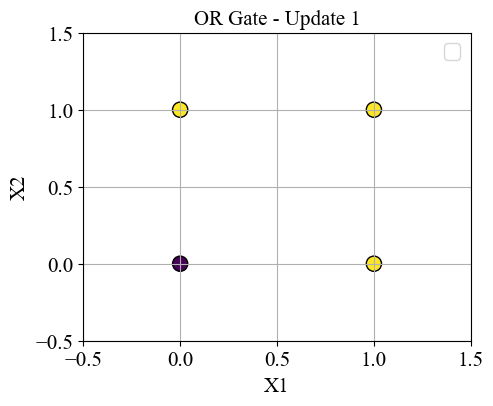

OR | Update 2 | Weights = [0.  0.1] | Bias = 0.00


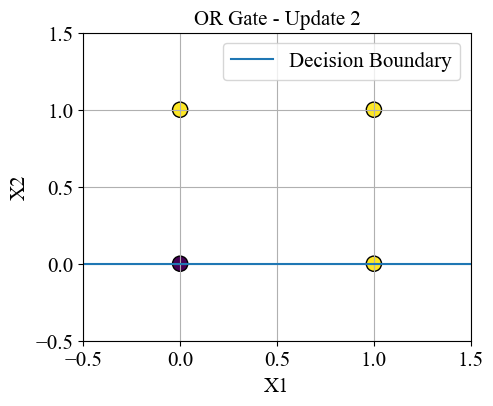

OR | Update 3 | Weights = [0.  0.1] | Bias = -0.10


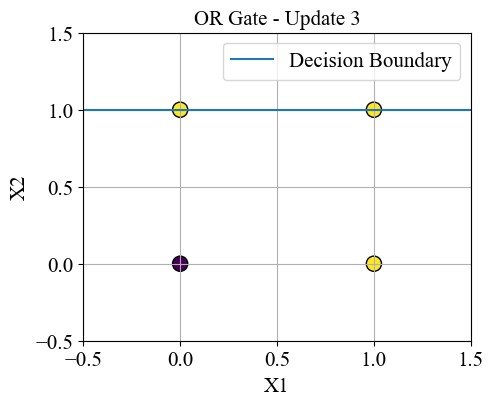

OR | Update 4 | Weights = [0.1 0.1] | Bias = 0.00


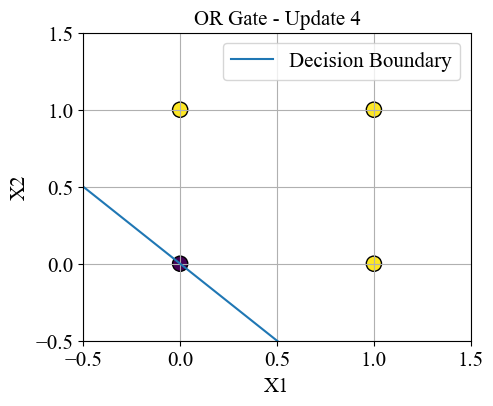

OR | Update 5 | Weights = [0.1 0.1] | Bias = -0.10


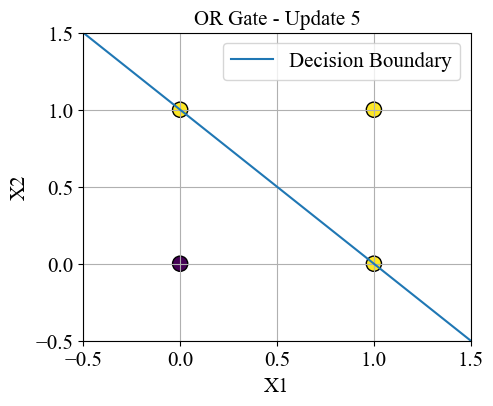


OR converged after 4 epochs.


In [20]:
or_weights, or_bias, or_history = train_gate(
    X_binary,
    y_or,
    "OR"
)


/tmp/ipykernel_4184/139276793.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


AND | Update 1 | Weights = [0. 0.] | Bias = -0.10


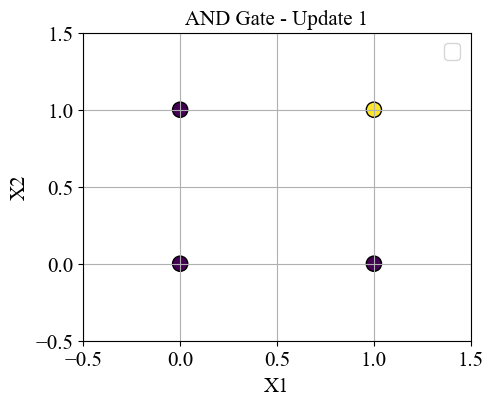

AND | Update 2 | Weights = [0.1 0.1] | Bias = 0.00


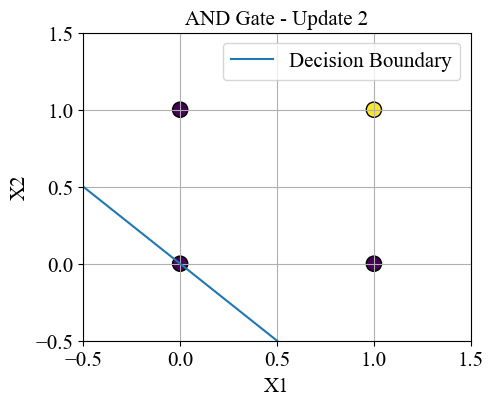

AND | Update 3 | Weights = [0.1 0.1] | Bias = -0.10


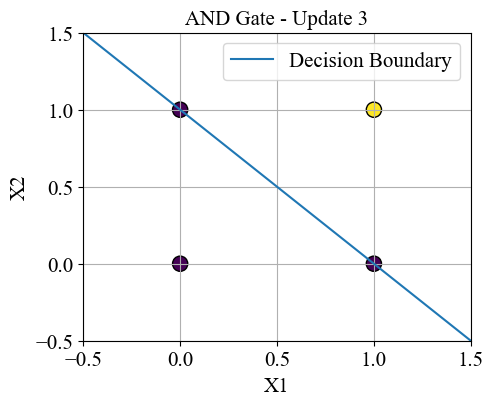

AND | Update 4 | Weights = [0.1 0. ] | Bias = -0.20


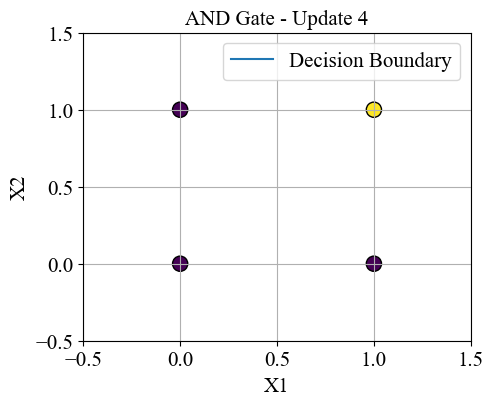

AND | Update 5 | Weights = [0.2 0.1] | Bias = -0.10


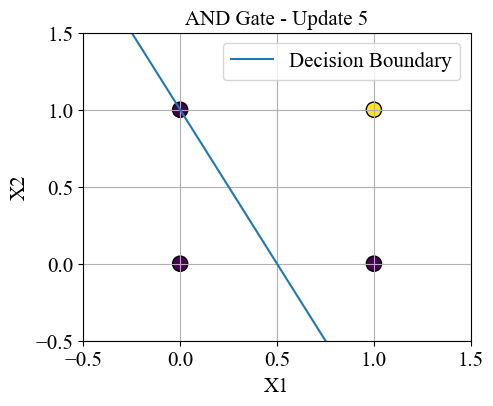

AND | Update 6 | Weights = [0.2 0. ] | Bias = -0.20


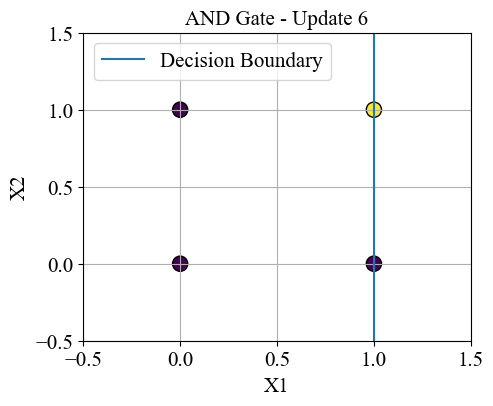

AND | Update 7 | Weights = [0.1 0. ] | Bias = -0.30


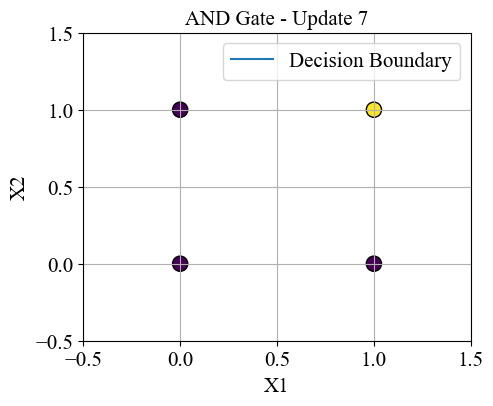

AND | Update 8 | Weights = [0.2 0.1] | Bias = -0.20


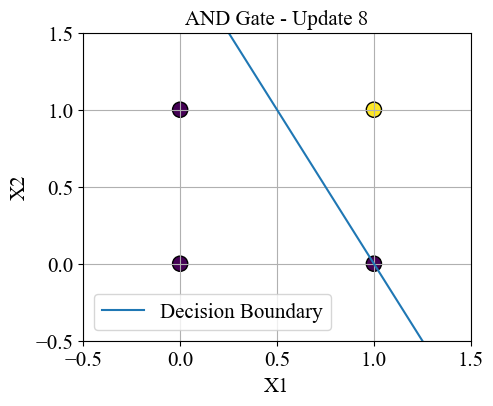


AND converged after 4 epochs.


In [21]:
and_weights, and_bias, and_history = train_gate(
    X_binary,
    y_and,
    "AND"
)


NOT | Update 1 | Weights = [-0.1] | Bias = -0.10


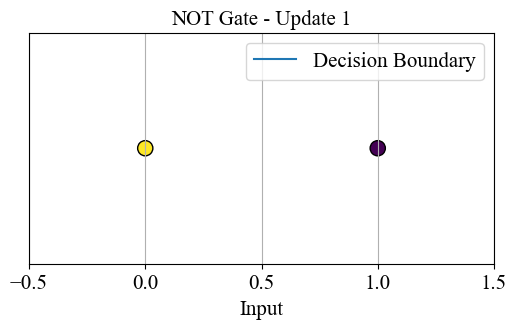

NOT | Update 2 | Weights = [-0.1] | Bias = 0.00


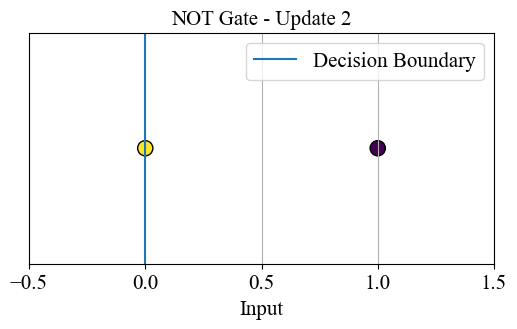


NOT converged after 3 epochs.


In [22]:
not_weights, not_bias, not_history = train_gate(
    X_not,
    y_not,
    "NOT"
)


In [14]:
or_table = pd.DataFrame(
    or_history,
    columns=[
        "Update", "Epoch",
        "W1", "W2", "Bias"
    ]
)

and_table = pd.DataFrame(
    and_history,
    columns=[
        "Update", "Epoch",
        "W1", "W2", "Bias"
    ]
)

not_table = pd.DataFrame(
    not_history,
    columns=[
        "Update", "Epoch",
        "W1", "Bias"
    ]
)

print("OR Gate Weight Updates")
display(or_table)

print("AND Gate Weight Updates")
display(and_table)

print("NOT Gate Weight Updates")
display(not_table)


OR Gate Weight Updates


,Update,Epoch,W1,W2,Bias
0,1,1,0.0,0.0,-0.1
1,2,1,0.0,0.1,0.0
2,3,2,0.0,0.1,-0.1
3,4,2,0.1,0.1,0.0
4,5,3,0.1,0.1,-0.1


AND Gate Weight Updates


,Update,Epoch,W1,W2,Bias
0,1,1,0.0,0.0,-0.1
1,2,1,0.1,0.1,0.0
2,3,2,0.1,0.1,-0.1
3,4,2,0.1,0.0,-0.2
4,5,2,0.2,0.1,-0.1
5,6,3,0.2,0.0,-0.2
6,7,3,0.1,0.0,-0.3
7,8,3,0.2,0.1,-0.2


NOT Gate Weight Updates


,Update,Epoch,W1,Bias
0,1,1,-0.1,-0.1
1,2,2,-0.1,0.0


In [15]:
def test_gate(X, y, weights, bias, gate):

    print(f"\n{gate} Gate")

    for x, target in zip(X, y):
        prediction = gate_step(
            np.dot(weights, x) + bias
        )

        print(
            f"Input: {x.astype(int)} "
            f"Target: {target} "
            f"Predicted: {prediction}"
        )

test_gate(
    X_binary,
    y_or,
    or_weights,
    or_bias,
    "OR"
)

test_gate(
    X_binary,
    y_and,
    and_weights,
    and_bias,
    "AND"
)

test_gate(
    X_not,
    y_not,
    not_weights,
    not_bias,
    "NOT"
)



OR Gate
Input: [0 0] Target: 0 Predicted: 0
Input: [0 1] Target: 1 Predicted: 1
Input: [1 0] Target: 1 Predicted: 1
Input: [1 1] Target: 1 Predicted: 1

AND Gate
Input: [0 0] Target: 0 Predicted: 0
Input: [0 1] Target: 0 Predicted: 0
Input: [1 0] Target: 0 Predicted: 0
Input: [1 1] Target: 1 Predicted: 1

NOT Gate
Input: [0] Target: 1 Predicted: 1
Input: [1] Target: 0 Predicted: 0
